# Assignment 06 — EC: how long will this delivery take? (Olist, Brazil)

**Author:** Lưu Anh Dũng (B23DCDK036) | **Course:** Intelligent System Development | **Lecturer:** Assoc. Prof. Dinh Que Tran, Ph.D.

**Dataset:** *Brazilian E-Commerce Public Dataset by Olist* (Kaggle `olistbr/brazilian-ecommerce`, 126 MB): about 99k orders placed on the Olist marketplace, 2016-09 → 2018-08, with every timestamp of the **service process** of an order:

```
purchase ──> payment approved ──> handed to carrier ──> delivered to customer      (+ promised date)
  t0              + hours              + days                 + days
```

**Task.** Orders to the same Brazilian state share trucks, carriers and bottlenecks, so the delivery times of recent orders say something about the next one. For each state, orders form one sequence in purchase order. Read the last **T = 10 orders to that state** — the 9 previous ones plus the new order itself, using only what is known **at purchase time** — and predict the **delivery time in days** of the new order (many-to-one regression, one model for all 27 states).
**Runs:** `EC-SC-RNN` (NumPy), `EC-TF-RNN` (Keras), `EC-PT-RNN` (PyTorch) from identical starting weights, plus LSTM and GRU in Keras and PyTorch. Formulas and operators: [00_rnn_concepts.ipynb](00_rnn_concepts.ipynb).

## 1. Setup

One seed and one set of hyper-parameters for all seven runs, so differences between scratch, Keras and PyTorch come from the implementation, not from tuning. Run IDs are `<dataset>-<implementation>-<model>` with `SC` = NumPy scratch, `TF` = Keras, `PT` = PyTorch. `A6_SMOKE=1` runs two states for 2 epochs into `smoke/` folders.

In [1]:
import os, time, json, random, warnings
from pathlib import Path
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")
os.environ.setdefault("TF_ENABLE_ONEDNN_OPTS", "0")
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import torch, torch.nn as nn, torch.nn.functional as Fn
from IPython.display import display
warnings.filterwarnings("ignore"); tf.get_logger().setLevel("ERROR")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 100, "savefig.dpi": 150, "savefig.bbox": "tight"})

SEED = 42
SMOKE = os.environ.get("A6_SMOKE") == "1"          # quick test: small data, 2 epochs, outputs go to */smoke/
tf.config.set_visible_devices([], "GPU")         # tensorflow-metal would put Keras on the Mac GPU; keep all three on CPU
random.seed(SEED); np.random.seed(SEED); keras.utils.set_random_seed(SEED); torch.manual_seed(SEED)

CODE = "EC"
DATA = Path("../dataset/ec")
RES = Path("results") / ("smoke" if SMOKE else "")
IMG = Path("../report/images") / ("smoke" if SMOKE else "")
RES.mkdir(parents=True, exist_ok=True); IMG.mkdir(parents=True, exist_ok=True)

H = 32            # hidden size: dimension of the state h_t
BATCH = 128       # windows per parameter update
LR = 1e-3         # Adam learning rate (constant)
EPS = 1e-7        # Adam epsilon (Keras default; set in PyTorch and scratch too)
CLIP = 1.0        # gradient clipping: global norm of all gradients
PATIENCE = 5      # early stopping patience (epochs) on the validation loss
MAX_EPOCHS = 2 if SMOKE else 30
T = 10            # window length (time steps read before each prediction)

# a 32-unit RNN on batches of 128 is too small to profit from a GPU; CPU keeps the three implementations comparable
dev = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("TensorFlow", tf.__version__, "| Keras", keras.__version__, "| PyTorch", torch.__version__, "| PT device:", dev, "| smoke:", SMOKE)

TensorFlow 2.18.1 | Keras 3.15.1 | PyTorch 2.14.1 | PT device: cpu | smoke: False


### Hyperparameters


| Name | Value | Meaning |
|---|---|---|
| Hidden size H | 32 | dimension of $h_t$ |
| Recurrent layers | 1 | one cell applied over the T steps, many-to-one |
| Activation | tanh | inside the cell; the output unit is linear |
| Loss | MSE | on the z-scored target |
| Optimizer | Adam | $\beta_1=0.9,\ \beta_2=0.999,\ \epsilon=10^{-7}$, lr $10^{-3}$ constant |
| Batch size | 128 | windows per update, reshuffled every epoch |
| Epochs | ≤ 30 | early stopping, patience 5, best weights restored |
| Gradient clipping | 1.0 | global norm of all gradients |
| Initial $W_{xh}$ / $W_{hh}$ / $W_{hy}$ | Glorot uniform / orthogonal / Glorot uniform | biases 0 |
| Seed, precision | 42, float32 | gradient check in float64 |

For this data: $F=10$ features per order, so the vanilla RNN has $10\cdot32+32\cdot32+32+32+1=1{,}409$ parameters — about one per 50 training windows, which is why early stopping matters here.

## 2. Data

**Building the sequences.**
1. Keep orders with status `delivered` and a delivery timestamp (96,470). Target $y$ = delivered − purchased, in days (e.g. bought Mon 10:00, delivered next Thu 16:00 → 10.25 days).
2. Join items (price, freight, number of items, seller), sellers and the geolocation table (mean latitude/longitude per zip prefix) to get the seller → customer distance.
3. Sort each customer state's orders by purchase time. A window = 10 consecutive orders of one state; its label is the delivery time of the **last** of them. A state with $n$ orders gives $n-9$ windows → ≈ 96k windows.

**No look-ahead.** At the moment order $k$ is placed, earlier orders may still be on the road, so their delivery times are *not* used as inputs. Every feature is known at purchase:

| Feature (per order) | Meaning | Transform / example |
|---|---|---|
| `promise` | promised delivery date − purchase, days | z. Olist promises generously: median 23 days vs 10 actual |
| `price`, `freight` | order value and shipping fee (BRL) | `log1p`, z: freight 15 → 2.77, 60 → 4.11 |
| `items` | number of items | `log1p`, z |
| `distance` | seller → customer, haversine km | `log1p`, z: 20 km (same city) vs 2,500 km (São Paulo → Belém) |
| `same_state` | seller and customer in the same state | 0/1 |
| `recent` | mean delivery time of this state's orders **delivered in the 7 days before** this purchase | z; known at purchase, carries the current congestion |
| `gap` | hours since the previous order to this state | `log1p`, z: the order rate |
| `dow_sin/cos` | weekday of purchase on a circle | Friday orders wait over the weekend |

**Target transform.** $\log(1+\text{days})$, z-scored: 5 → 1.79, 10 → 2.40, 40 → 3.71, so the rare 100-day disasters do not dominate the squared error. Metrics are reported back in days.

**Split.** Chronological by the purchase time of the predicted order: first 70 % train, next 15 % validation, last 15 % test (2018-06-21 → 2018-08-29; the truckers' strike of late May 2018 falls in validation). Scaler statistics use train orders only.

**Metrics.** RMSE and MAE in days, `hit3` = share of predictions within ±3 days, RMSE on the z-scale, $R^2_{oos}$ vs the train mean.
**Baselines.** *Train mean*; *recent state mean* (the `recent` feature itself: "it will take as long as last week's deliveries to this state"); *promise regression* (least squares on the promised days, i.e. Olist's own estimate, recalibrated); *linear model* on the 100 flattened window values.

In [2]:
SMOKE_STATES = ["RJ", "MG"]
FEATS = ["promise", "price", "freight", "items", "distance", "same_state", "recent", "gap", "dow_sin", "dow_cos"]
ZCOLS = [0, 1, 2, 3, 4, 6, 7]

ts = ["order_purchase_timestamp", "order_delivered_customer_date", "order_estimated_delivery_date"]
o = pd.read_csv(DATA / "olist_orders_dataset.csv", parse_dates=ts)
o = o.merge(pd.read_csv(DATA / "olist_customers_dataset.csv"), on="customer_id")
it = pd.read_csv(DATA / "olist_order_items_dataset.csv").merge(pd.read_csv(DATA / "olist_sellers_dataset.csv"), on="seller_id")
geo = pd.read_csv(DATA / "olist_geolocation_dataset.csv").groupby("geolocation_zip_code_prefix")[["geolocation_lat", "geolocation_lng"]].mean()
print(f"{len(o):,} orders, {len(it):,} order items, {len(geo):,} zip prefixes with coordinates")

d = o[(o.order_status == "delivered") & o.order_delivered_customer_date.notna()].copy()
if SMOKE: d = d[d.customer_state.isin(SMOKE_STATES)]
agg = it.groupby("order_id").agg(price=("price", "sum"), freight=("freight_value", "sum"), items=("order_item_id", "size"),
                                 seller_zip=("seller_zip_code_prefix", "first"), seller_state=("seller_state", "first"))
d = d.join(agg, on="order_id").dropna(subset=["price"])
def coords(z): return geo.reindex(z).to_numpy()
a, b = np.radians(coords(d.customer_zip_code_prefix)), np.radians(coords(d.seller_zip))
hav = np.sin((b[:, 0] - a[:, 0]) / 2) ** 2 + np.cos(a[:, 0]) * np.cos(b[:, 0]) * np.sin((b[:, 1] - a[:, 1]) / 2) ** 2
d["km"] = 6371 * 2 * np.arcsin(np.sqrt(hav)); d["km"] = d.km.fillna(d.km.median())   # 0.4 % of zips have no coordinates
d["days"] = (d.order_delivered_customer_date - d.order_purchase_timestamp).dt.total_seconds() / 86400
d["promise"] = (d.order_estimated_delivery_date - d.order_purchase_timestamp).dt.total_seconds() / 86400
d = d.sort_values(["customer_state", "order_purchase_timestamp"]).reset_index(drop=True)

# recent: mean delivery time of the state's orders delivered in [purchase - 7 days, purchase)
d["recent"] = np.nan
for s_, g in d.groupby("customer_state"):
    dl = g.sort_values("order_delivered_customer_date"); t_del = dl.order_delivered_customer_date.to_numpy()
    cs = np.r_[0, np.cumsum(dl.days.to_numpy())]
    p = g.order_purchase_timestamp.to_numpy()
    hi = np.searchsorted(t_del, p); lo = np.searchsorted(t_del, p - np.timedelta64(7, "D"))
    n = hi - lo; d.loc[g.index, "recent"] = np.where(n > 0, (cs[hi] - cs[lo]) / np.maximum(n, 1), np.nan)
d["gap"] = d.groupby("customer_state").order_purchase_timestamp.diff().dt.total_seconds().div(3600).fillna(24)
print(f"{len(d):,} delivered orders in {d.customer_state.nunique()} states; delivery days median {d.days.median():.1f}, "
      f"promise median {d.promise.median():.1f}, late {(d.days > d.promise).mean():.1%}")

A = np.zeros((len(d), len(FEATS)), np.float32)
A[:, 0] = d.promise; A[:, 1] = np.log1p(d.price); A[:, 2] = np.log1p(d.freight); A[:, 3] = np.log1p(d["items"])
A[:, 4] = np.log1p(d.km); A[:, 5] = d.seller_state == d.customer_state; A[:, 6] = d.recent; A[:, 7] = np.log1p(d.gap)
dow = d.order_purchase_timestamp.dt.dayofweek.to_numpy()
A[:, 8], A[:, 9] = np.sin(2 * np.pi * dow / 7), np.cos(2 * np.pi * dow / 7)
Y = np.log1p(d.days.to_numpy()).astype(np.float32)

# windows: 10 consecutive orders of one state, label = delivery time of the last one
first = d.groupby("customer_state").cumcount().to_numpy()                  # position inside the state
ends = np.where(first >= T - 1)[0]
tp = d.order_purchase_timestamp.to_numpy()[ends]
cut1, cut2 = np.quantile(tp.astype("int64"), [0.70, 0.85]).astype("int64").astype(tp.dtype)   # same time unit as tp
split = np.where(tp < cut1, 0, np.where(tp < cut2, 1, 2))

train_rows = d.order_purchase_timestamp.to_numpy() < cut1                  # scaler: train-period orders only
A[:, 6] = np.where(np.isnan(A[:, 6]), np.nanmean(A[train_rows, 6]), A[:, 6])   # first week of a state: no history yet
mu = A[train_rows][:, ZCOLS].mean(0); sd = A[train_rows][:, ZCOLS].std(0)
A[:, ZCOLS] = (A[:, ZCOLS] - mu) / sd
mu_t, sd_t = float(Y[train_rows].mean()), float(Y[train_rows].std())
Yz = (Y - mu_t) / sd_t

def gather(s):
    e = ends[split == s]
    return A[e[:, None] + np.arange(-T + 1, 1)], Yz[e].copy(), e
Xtr, ytr, tr_end = gather(0); Xva, yva, va_end = gather(1); Xte, yte, te_end = gather(2)
if not SMOKE: np.savez(DATA / "splits.npz", cut1=str(cut1), cut2=str(cut2), T=T, mu=mu, sd=sd, mu_t=mu_t, sd_t=sd_t, n=[len(ytr), len(yva), len(yte)])
print(f"windows: train {len(Xtr):,} | validation {len(Xva):,} | test {len(Xte):,} | total {len(Xtr)+len(Xva)+len(Xte):,}")
print(f"X shape (N, T, F) = {Xtr.shape} | train < {str(cut1)[:10]} <= validation < {str(cut2)[:10]} <= test")

99,441 orders, 112,650 order items, 19,015 zip prefixes with coordinates
96,470 delivered orders in 27 states; delivery days median 10.2, promise median 23.2, late 8.1%


windows: train 67,359 | validation 14,434 | test 14,434 | total 96,227
X shape (N, T, F) = (67359, 10, 10) | train < 2018-04-16 <= validation < 2018-06-21 <= test


**Shape trace.** `X[i]` is $(10, 10)$: rows 1–9 are the previous nine orders to the same state (oldest first), row 10 is the order whose delivery time is predicted; `y[i]` is one z-scored $\log(1+\text{days})$. A batch is $(128, 10, 10)$ = `(batch, time, features)`, the layout of `SimpleRNN` and `nn.RNN(batch_first=True)`.

In [3]:
to_days = lambda z: np.expm1(np.asarray(z) * sd_t + mu_t)
ybar = float(ytr.mean())
KEY_METRIC = "rmse_days"
def metrics_fn(z_true, z_pred):
    dt, dp = to_days(z_true), to_days(z_pred)
    return dict(rmse_days=float(np.sqrt(np.mean((dt - dp) ** 2))), mae_days=float(np.mean(np.abs(dt - dp))),
                hit3=float(np.mean(np.abs(dt - dp) <= 3)), rmse=float(np.sqrt(np.mean((z_true - z_pred) ** 2))),
                r2_oos=float(1 - np.sum((z_true - z_pred) ** 2) / np.sum((z_true - ybar) ** 2)))

def ols(cols_tr, cols_te):
    beta = np.linalg.lstsq(np.c_[cols_tr, np.ones(len(cols_tr))].astype(np.float64), ytr.astype(np.float64), rcond=None)[0]
    return (np.c_[cols_te, np.ones(len(cols_te))] @ beta).astype(np.float32)
flat = lambda X: X.reshape(len(X), -1)
recent_z = lambda X: ((np.log1p(X[:, -1, 6] * sd[5] + mu[5])) - mu_t) / sd_t          # recent mean days -> target scale
BASELINES = {"train mean": np.full(len(yte), ybar, np.float32),
             "recent state mean (last 7 days)": recent_z(Xte).astype(np.float32),
             "promise regression (OLS on promised days)": ols(Xtr[:, -1, :1], Xte[:, -1, :1]),
             "linear model on window (OLS)": ols(flat(Xtr), flat(Xte))}
display(pd.DataFrame({k: metrics_fn(yte, v) for k, v in BASELINES.items()}).T.round(4))

SHOW = "RJ" if "RJ" in set(d.customer_state) else d.customer_state.iloc[0]
state_te = d.customer_state.to_numpy()[te_end]
def overlay_slice(pred, n=120):
    ix = np.where(state_te == SHOW)[0][-n:]
    return d.order_purchase_timestamp.to_numpy()[te_end[ix]], to_days(yte[ix]), to_days(pred[ix]), "purchase time", f"delivery days, orders to {SHOW}"

,rmse_days,mae_days,hit3,rmse,r2_oos
train mean,6.2279,5.0199,0.2827,1.1034,0.0000
recent state mean (last 7 days),5.2151,3.4438,0.5660,0.8021,0.4716
promise regression (OLS on promised days),5.4078,3.6820,0.5383,0.8163,0.4527
linear model on window (OLS),5.2629,3.8280,0.4896,0.7920,0.4848


`recent` is stored z-scored, so the baseline first undoes the z-score ($\times\sigma+\mu$) to get days, then maps days to the target scale. Example: a recent mean of 9 days → $\log(10)=2.30$ → z $=(2.30-\mu_t)/\sigma_t$.

### Shared evaluation helpers

`finalize` predicts validation and test, writes `results/<run_id>.json`, saves the loss and forecast figures, prints a summary. Time per epoch is the median of epochs 2+.

In [4]:
RUNS = {}   # run_id -> result record (+ test predictions)

def median_epoch_time(times):
    times = list(times)
    return float(np.median(times[1:] if len(times) > 1 else times))   # epoch 1 includes one-time set-up

def infer_ms_per_1k(predict_fn, X, reps=3):
    n = min(len(X), 10000); ts = []
    for _ in range(reps):
        t0 = time.perf_counter(); predict_fn(X[:n]); ts.append(time.perf_counter() - t0)
    return float(np.median(ts)) / n * 1e6

def plot_loss(run_id, hist):
    best = int(np.argmin(hist["val_loss"]))
    fig, ax = plt.subplots(figsize=(5.5, 3.4))
    ax.plot(range(1, len(hist["loss"]) + 1), hist["loss"], label="train")
    ax.plot(range(1, len(hist["val_loss"]) + 1), hist["val_loss"], label="validation")
    ax.axvline(best + 1, ls=":", c="grey"); ax.set(xlabel="epoch", ylabel="MSE (z-scored target)", title=f"{run_id}: loss"); ax.legend()
    fig.savefig(IMG / f"{run_id}_loss.png"); plt.show()

def plot_forecast(run_id, pred):
    xs, actual, predicted, xlabel, ylabel = overlay_slice(pred)
    fig, (a, b) = plt.subplots(1, 2, figsize=(11, 3.4), gridspec_kw={"width_ratios": [2.2, 1]})
    a.plot(xs, actual, label="actual", lw=1.5, marker=".", ms=4); a.plot(xs, predicted, label=run_id, lw=1.2)
    a.set(xlabel=xlabel, ylabel=ylabel, title=f"{run_id}: one series on the test period"); a.legend(); a.tick_params(axis="x", rotation=30)
    b.hist(yte - pred, bins=80, color="C2"); b.set(xlabel="residual (z-scored target)", title="residuals, all test windows")
    fig.savefig(IMG / f"{run_id}_forecast.png"); plt.show()

def finalize(run_id, impl, kind, hist, params, times, total, predict_fn):
    pv, pt = predict_fn(Xva), predict_fn(Xte)
    rec = dict(run_id=run_id, impl=impl, model=kind, params=int(params), epochs_run=len(hist["loss"]),
               best_epoch=int(np.argmin(hist["val_loss"]) + 1), time_per_epoch_s=median_epoch_time(times),
               total_time_s=float(total), infer_ms_per_1k=infer_ms_per_1k(predict_fn, Xte),
               val=metrics_fn(yva, pv), test=metrics_fn(yte, pt),
               history={k: [float(v) for v in vs] for k, vs in hist.items()})
    (RES / f"{run_id}.json").write_text(json.dumps(rec, indent=1))
    RUNS[run_id] = dict(rec, pred=pt)
    plot_loss(run_id, hist); plot_forecast(run_id, pt)
    print(f"{run_id}: params {rec['params']:,} | epochs {rec['epochs_run']} (best {rec['best_epoch']}) | "
          f"{rec['time_per_epoch_s']:.1f}s/epoch | total {rec['total_time_s']:.0f}s | test " +
          ", ".join(f"{k} {v:.4f}" for k, v in rec["test"].items()))
    return rec

## 3. Exploratory data analysis

Questions for the plots: (1) how skewed is the delivery time, and how does it compare with the promise? (2) does it move over **time** in a way that recent orders can reveal (congestion, holidays, strikes)? (3) how much does geography explain?

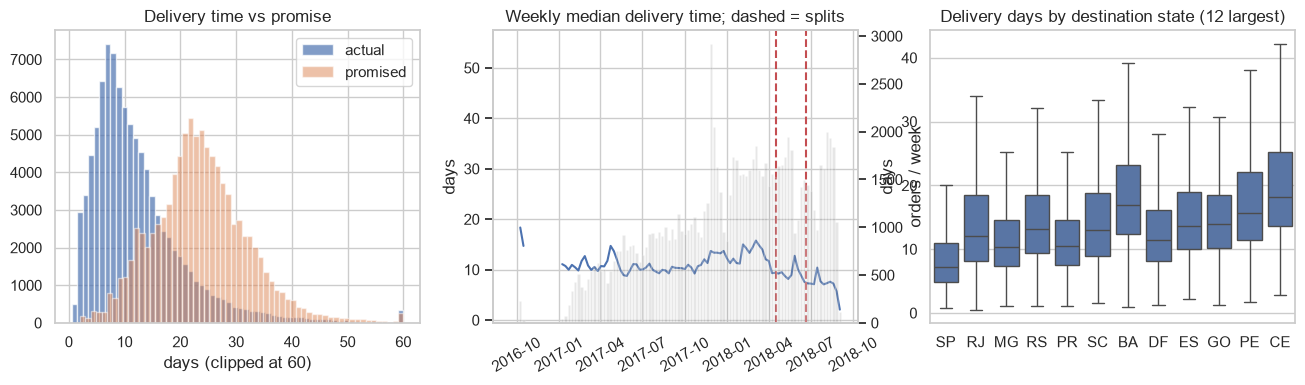

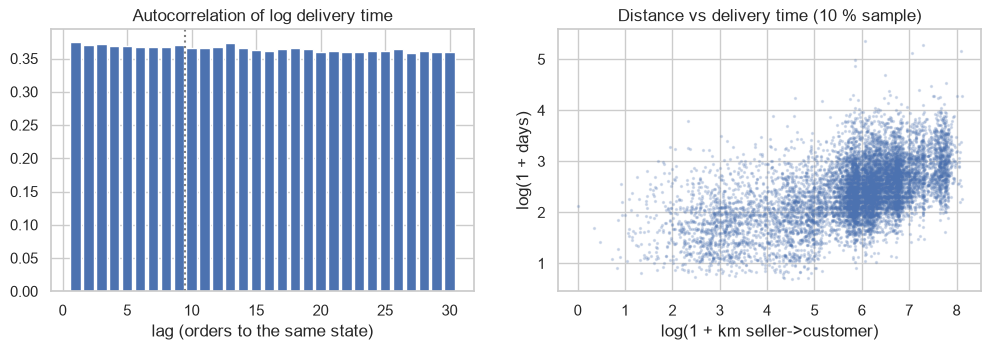

corr(log days, log km) = 0.55 | corr(days, promise) = 0.38 | lag-1 r = 0.37, lag-9 r = 0.37


In [5]:
fig, ax = plt.subplots(1, 3, figsize=(16, 3.8))
ax[0].hist(d.days.clip(upper=60), bins=60, alpha=.7, label="actual"); ax[0].hist(d.promise.clip(upper=60), bins=60, alpha=.5, label="promised")
ax[0].set(xlabel="days (clipped at 60)", title="Delivery time vs promise"); ax[0].legend()
daily = d.set_index("order_purchase_timestamp").days.resample("W").median()
cnt = d.set_index("order_purchase_timestamp").days.resample("W").size()
ax[1].plot(daily.index, daily.values, label="median delivery days"); ax[1].set(ylabel="days", title="Weekly median delivery time; dashed = splits")
ax2 = ax[1].twinx(); ax2.bar(cnt.index, cnt.values, width=5, alpha=.2, color="grey"); ax2.set(ylabel="orders / week"); ax2.grid(False)
for c_ in (cut1, cut2): ax[1].axvline(c_, c="C3", ls="--")
ax[1].tick_params(axis="x", rotation=30)
top = d.customer_state.value_counts().index[:12]
sns.boxplot(data=d[d.customer_state.isin(top)], x="customer_state", y="days", order=list(top), ax=ax[2], showfliers=False)
ax[2].set(title="Delivery days by destination state (12 largest)", xlabel="")
fig.savefig(IMG / f"{CODE}_eda_delivery.png"); plt.show()

dd = d.days.to_numpy(); st_ = d.customer_state.to_numpy()
def lag_r(k):
    same = st_[:-k] == st_[k:]
    return np.corrcoef(np.log1p(dd[:-k][same]), np.log1p(dd[k:][same]))[0, 1]
r = [lag_r(k) for k in range(1, 31)]
fig, ax = plt.subplots(1, 2, figsize=(12, 3.4))
ax[0].bar(range(1, 31), r); ax[0].axvline(T - .5, c="grey", ls=":"); ax[0].set(xlabel="lag (orders to the same state)", title="Autocorrelation of log delivery time")
ax[1].scatter(np.log1p(d.km)[::10], np.log1p(d.days)[::10], s=2, alpha=.2); ax[1].set(xlabel="log(1 + km seller->customer)", ylabel="log(1 + days)", title="Distance vs delivery time (10 % sample)")
fig.savefig(IMG / f"{CODE}_eda_memory.png"); plt.show()
print(f"corr(log days, log km) = {np.corrcoef(np.log1p(d.km), np.log1p(d.days))[0,1]:.2f} | corr(days, promise) = {np.corrcoef(d.days, d.promise)[0,1]:.2f} | "
      f"lag-1 r = {r[0]:.2f}, lag-9 r = {r[8]:.2f}")

**Reading.** Delivery time is right-skewed (median ≈ 10 days, a tail beyond 40), and the promise is set far above it, so Olist is late on only ~8 % of orders. The weekly median is not flat: it jumps around Black Friday (Nov 2017) and the truckers' strike (late May 2018, in the validation period) — a shift that the recent orders of a state reveal before the calendar does. Successive orders to the same state stay correlated over many lags, which is the signal a recurrent model can collect; distance and state explain the rest.

## 4. RNN from scratch (NumPy) — run `EC-SC-RNN`

**Forward.** $h_t=\tanh(x_tW_{xh}+h_{t-1}W_{hh}+b)$ for the 10 orders, $h_0=0$; $\hat y=h_{10}W_{hy}+b_y$. The first nine steps let the state build a picture of "how the state's logistics are doing", the tenth step adds the new order's own distance, price and promise.

**Backward (BPTT).** With $z_t$ the pre-activation and $L=\frac1N\sum(\hat y-y)^2$:

$$\delta_{10}=\tfrac2N(\hat y-y)W_{hy}^\top,\quad \frac{\partial L}{\partial z_t}=\delta_t\odot(1-h_t^2),\quad \delta_{t-1}=\frac{\partial L}{\partial z_t}W_{hh}^\top,\quad \frac{\partial L}{\partial W_{xh}}=\sum_{t=1}^{10}x_t^\top\frac{\partial L}{\partial z_t}.$$

Example of the error signal: true 8 days, predicted 12 → on the target scale $\log 13-\log 9=0.37$ nats, i.e. $(0.37/\sigma_t)$ in z-units; the gradient at the output is $2\cdot$ that error $/N$.

**Shapes here.** $(128,10,10)$ → `X @ Wxh` $(128,10,32)$ → 10 steps on $(128,32)$ → $(128,)$. Parameters $W_{xh}$ 320, $W_{hh}$ 1,024, $b$ 32, $W_{hy}$ 32, $b_y$ 1 → **1,409**.

In [6]:
class ScratchRNN:
    """Single-layer vanilla RNN, many-to-one: h_t = tanh(x_t Wxh + h_{t-1} Whh + b), yhat = h_T Why + by. NumPy only."""
    def __init__(self, F, H, seed=SEED, dtype=np.float32):
        rng = np.random.default_rng(seed)
        lim = np.sqrt(6 / (F + H))                                   # Glorot uniform (Keras kernel default)
        q, r = np.linalg.qr(rng.standard_normal((H, H)))             # orthogonal recurrent matrix (Keras default)
        lh = np.sqrt(6 / (H + 1))
        self.p = {"Wxh": rng.uniform(-lim, lim, (F, H)), "Whh": q * np.sign(np.diag(r)), "bh": np.zeros(H),
                  "Why": rng.uniform(-lh, lh, (H, 1)), "by": np.zeros(1)}
        self.p = {k: v.astype(dtype) for k, v in self.p.items()}

    def n_params(self): return int(sum(v.size for v in self.p.values()))

    def forward(self, X):
        p = self.p; N, Tn, _ = X.shape
        xw = X @ p["Wxh"]                                            # input part of every step at once: (N, T, H)
        h = np.zeros((N, p["Whh"].shape[0]), X.dtype); hs = [h]
        for t in range(Tn):                                          # the recurrence itself cannot be vectorised over t
            h = np.tanh(xw[:, t] + h @ p["Whh"] + p["bh"]); hs.append(h)
        return (h @ p["Why"] + p["by"])[:, 0], hs

    def loss_grads(self, X, y):
        """MSE and its gradients by back-propagation through time; also ||dL/dh_t|| for t = 1..T."""
        p = self.p; yhat, hs = self.forward(X); N, Tn, _ = X.shape
        err = yhat - y; loss = float(np.mean(err ** 2))
        dy = (2.0 / N) * err[:, None]                                # dL/dyhat, (N, 1)
        g = {k: np.zeros_like(v) for k, v in p.items()}
        g["Why"] = hs[-1].T @ dy; g["by"] = dy.sum(0)
        dh = dy @ p["Why"].T                                         # dL/dh_T, (N, H)
        norms = np.zeros(Tn)
        for t in range(Tn, 0, -1):
            norms[t - 1] = np.linalg.norm(dh)
            dz = dh * (1.0 - hs[t] ** 2)                             # back through tanh
            g["Wxh"] += X[:, t - 1].T @ dz                           # shared weights: add every step's share
            g["Whh"] += hs[t - 1].T @ dz
            g["bh"] += dz.sum(0)
            dh = dz @ p["Whh"].T                                     # hand the signal to step t-1
        return loss, g, norms

    def predict(self, X, bs=4096):
        return np.concatenate([self.forward(X[i:i + bs])[0] for i in range(0, len(X), bs)])


class Adam:
    """m <- b1 m + (1-b1) g ; v <- b2 v + (1-b2) g^2 ; theta <- theta - lr * m_hat / (sqrt(v_hat) + eps)."""
    def __init__(self, params, lr=LR, b1=0.9, b2=0.999, eps=EPS):
        self.lr, self.b1, self.b2, self.eps, self.t = lr, b1, b2, eps, 0
        self.m = {k: np.zeros_like(v) for k, v in params.items()}; self.v = {k: np.zeros_like(v) for k, v in params.items()}
    def step(self, params, grads):
        self.t += 1
        for k in params:
            self.m[k] = self.b1 * self.m[k] + (1 - self.b1) * grads[k]
            self.v[k] = self.b2 * self.v[k] + (1 - self.b2) * grads[k] ** 2
            mh = self.m[k] / (1 - self.b1 ** self.t); vh = self.v[k] / (1 - self.b2 ** self.t)
            params[k] -= self.lr * mh / (np.sqrt(vh) + self.eps)


def clip_global_norm(grads, max_norm=CLIP):
    total = np.sqrt(sum(float((g.astype(np.float64) ** 2).sum()) for g in grads.values()))
    scale = min(1.0, max_norm / (total + 1e-6))
    for k in grads: grads[k] *= scale
    return total


def fit_scratch(model, Xtr, ytr, Xva, yva):
    opt = Adam(model.p); rng = np.random.default_rng(SEED)
    hist = {"loss": [], "val_loss": []}; times = []; best, wait, best_p = np.inf, 0, None
    t_all = time.perf_counter()
    for ep in range(MAX_EPOCHS):
        t0 = time.perf_counter(); perm = rng.permutation(len(Xtr)); tot = 0.0
        for i in range(0, len(perm), BATCH):
            idx = perm[i:i + BATCH]
            loss, g, _ = model.loss_grads(Xtr[idx], ytr[idx])
            clip_global_norm(g); opt.step(model.p, g); tot += loss * len(idx)
        val = float(np.mean((model.predict(Xva) - yva) ** 2))
        hist["loss"].append(tot / len(perm)); hist["val_loss"].append(val); times.append(time.perf_counter() - t0)
        if val < best - 1e-12: best, wait, best_p = val, 0, {k: v.copy() for k, v in model.p.items()}
        else: wait += 1
        if wait >= PATIENCE: break
    model.p = best_p                                                 # restore the best epoch
    return hist, times, time.perf_counter() - t_all

### Gradient check

Analytic BPTT gradients vs central differences $\frac{L(\theta+\epsilon)-L(\theta-\epsilon)}{2\epsilon}$ ($\epsilon=10^{-6}$, float64) for all 1,409 parameters on 8 real windows; pass if $\max|a-n|/\max|a|<10^{-5}$.

In [7]:
def gradient_check(F, n=8, eps=1e-6, seed=0):
    """Analytic BPTT gradients vs central finite differences, float64, on n real windows."""
    m = ScratchRNN(F, H, seed=seed, dtype=np.float64)
    for k in ("bh", "by"): m.p[k] = np.random.default_rng(1).normal(0, 0.1, m.p[k].shape)      # non-zero biases
    X, y = Xtr[:n].astype(np.float64), ytr[:n].astype(np.float64)
    _, g, _ = m.loss_grads(X, y); rows = []
    for k, v in m.p.items():
        num = np.zeros_like(v)
        for ix in np.ndindex(*v.shape):
            old = v[ix]; v[ix] = old + eps; lp = m.loss_grads(X, y)[0]; v[ix] = old - eps; lm = m.loss_grads(X, y)[0]; v[ix] = old
            num[ix] = (lp - lm) / (2 * eps)
        rows.append((k, v.shape, float(np.abs(g[k] - num).max() / max(np.abs(g[k]).max(), 1e-12))))
    return pd.DataFrame(rows, columns=["parameter", "shape", "max error / max |gradient|"])

gc = gradient_check(Xtr.shape[2]); display(gc)
assert gc["max error / max |gradient|"].max() < 1e-5, "BPTT gradients disagree with finite differences"

,parameter,shape,max error / max |gradient|
0,Wxh,"(10, 32)",2.127553e-10
1,Whh,"(32, 32)",8.198844e-10
2,bh,"(32,)",5.694913e-10
3,Why,"(32, 1)",1.099635e-10
4,by,"(1,)",8.481007e-12


### Training

`W0` (Glorot input, orthogonal recurrent, zero bias) is drawn once and copied into Keras and PyTorch. One epoch ≈ 67k windows / 128 ≈ 520 Adam updates with global-norm clipping (a gradient of norm 2.5 is scaled by 0.4).

scratch parameters: 1409  = F*H + H*H + H + H + 1 = 1409


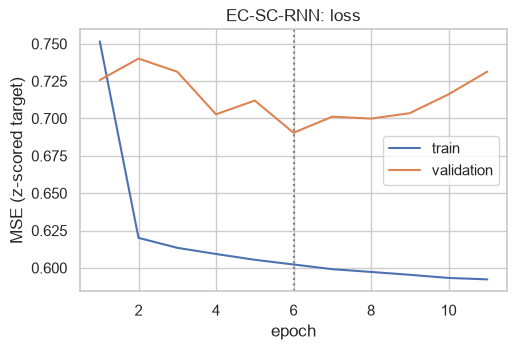

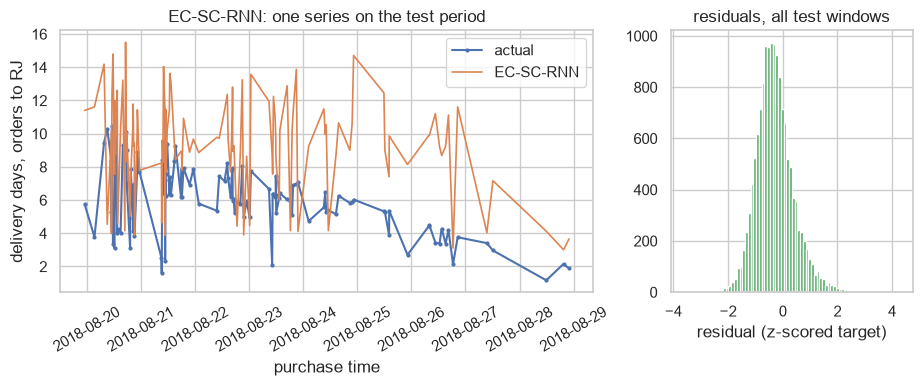

EC-SC-RNN: params 1,409 | epochs 11 (best 6) | 0.2s/epoch | total 3s | test rmse_days 5.0136, mae_days 3.5049, hit3 0.5461, rmse 0.7458, r2_oos 0.5432


In [8]:
F_ = Xtr.shape[2]
W0 = {k: v.copy() for k, v in ScratchRNN(F_, H).p.items()}          # starting weights shared by all three core runs
sc = ScratchRNN(F_, H)
print("scratch parameters:", sc.n_params(), " = F*H + H*H + H + H + 1 =", F_ * H + H * H + H + H + 1)
hist, times, total = fit_scratch(sc, Xtr, ytr, Xva, yva)
finalize(f"{CODE}-SC-RNN", "Scratch", "RNN", hist, sc.n_params(), times, total, sc.predict);

### How far back does the signal reach?

$\lVert\partial L/\partial h_t\rVert$ for the 10 orders relative to the newest one. If the oldest order still gets a sizeable share, the network can learn from congestion that built up over the last ~10 orders, not just from the current order's own features.

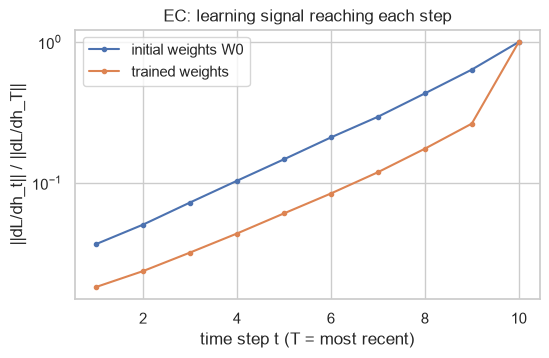

oldest step receives 0.018 of the newest step's gradient (trained), 0.037 (initial)


In [9]:
idx = np.random.default_rng(0).choice(len(Xte), 512, replace=False)
trained = sc.p; norms_trained = sc.loss_grads(Xte[idx], yte[idx])[2]
sc.p = {k: v.copy() for k, v in W0.items()}; norms_init = sc.loss_grads(Xte[idx], yte[idx])[2]; sc.p = trained
fig, ax = plt.subplots(figsize=(6, 3.5))
for n_, l_ in ((norms_init, "initial weights W0"), (norms_trained, "trained weights")):
    ax.semilogy(range(1, T + 1), n_ / n_[-1], marker="o", ms=3, label=l_)
ax.set(xlabel="time step t (T = most recent)", ylabel="||dL/dh_t|| / ||dL/dh_T||", title=f"{CODE}: learning signal reaching each step"); ax.legend()
fig.savefig(IMG / f"{CODE}-SC-RNN_gradnorm.png"); plt.show()
print(f"oldest step receives {norms_trained[0] / norms_trained[-1]:.3f} of the newest step's gradient (trained), "
      f"{norms_init[0] / norms_init[-1]:.3f} (initial)")

## 5. RNN in Keras — runs `EC-TF-RNN`, `EC-TF-LSTM`, `EC-TF-GRU`

`SimpleRNN(32)` (loop + tanh recurrence), `Dense(1)` (head), `fit` (shuffling, Adam with `global_clipnorm=1.0`, early stopping with best weights restored). `W0` goes in with `set_weights([kernel (10,32), recurrent_kernel (32,32), bias (32)])` — the same $xW$ orientation as NumPy, no transpose.

In [10]:
def build_keras(kind, F, Tn, copy_init=None):
    cell = {"RNN": layers.SimpleRNN, "LSTM": layers.LSTM, "GRU": layers.GRU}[kind]
    m = keras.Sequential([layers.Input((Tn, F)), cell(H), layers.Dense(1)])
    m.compile(optimizer=keras.optimizers.Adam(LR, epsilon=EPS, global_clipnorm=CLIP), loss="mse")
    if copy_init is not None:                                        # SimpleRNN weights: [kernel (F,H), recurrent_kernel (H,H), bias (H)]
        m.layers[0].set_weights([copy_init["Wxh"], copy_init["Whh"], copy_init["bh"]])
        m.layers[1].set_weights([copy_init["Why"], copy_init["by"]])
    return m

class EpochTimer(keras.callbacks.Callback):
    def on_train_begin(self, logs=None): self.times = []
    def on_epoch_begin(self, epoch, logs=None): self.t0 = time.perf_counter()
    def on_epoch_end(self, epoch, logs=None): self.times.append(time.perf_counter() - self.t0)

def run_keras(kind, copy_init=None):
    run_id = f"{CODE}-TF-{kind}"; keras.utils.set_random_seed(SEED)
    m = build_keras(kind, Xtr.shape[2], Xtr.shape[1], copy_init)
    timer = EpochTimer(); es = keras.callbacks.EarlyStopping(monitor="val_loss", patience=PATIENCE, restore_best_weights=True)
    t0 = time.perf_counter()
    h = m.fit(Xtr, ytr, validation_data=(Xva, yva), batch_size=BATCH, epochs=MAX_EPOCHS, shuffle=True, callbacks=[es, timer], verbose=0)
    total = time.perf_counter() - t0
    pred = lambda X: m.predict(X, batch_size=4096, verbose=0)[:, 0]
    return finalize(run_id, "Keras", kind, h.history, m.count_params(), timer.times, total, pred)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 32)             │         1,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,409 (5.50 KB)

 Trainable params: 1,409 (5.50 KB)

 Non-trainable params: 0 (0.00 B)

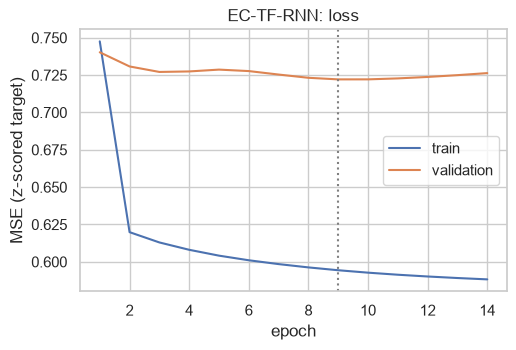

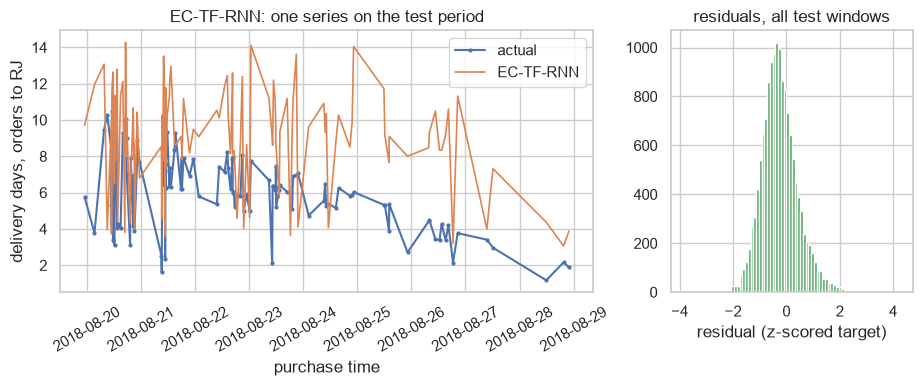

EC-TF-RNN: params 1,409 | epochs 14 (best 9) | 0.6s/epoch | total 10s | test rmse_days 4.9676, mae_days 3.4069, hit3 0.5718, rmse 0.7340, r2_oos 0.5575


In [11]:
build_keras("RNN", Xtr.shape[2], T, W0).summary()
run_keras("RNN", copy_init=W0);

**LSTM and GRU.** Framework-default initialisation. For $F=10,H=32$: GRU $3\cdot(10\cdot32+32\cdot32+2\cdot32)=4{,}224$, LSTM $4\cdot(10\cdot32+32\cdot32+32)=5{,}504$, plus the 33-parameter head. A gate could, for example, learn to ignore old orders when the `gap` feature says the state was quiet for days.

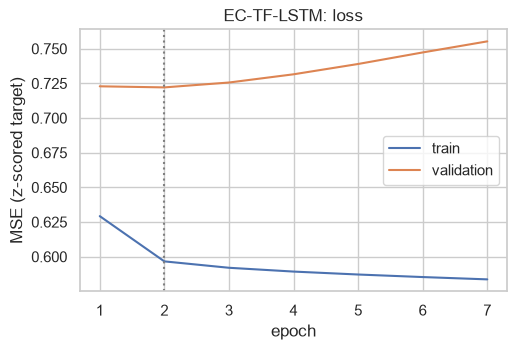

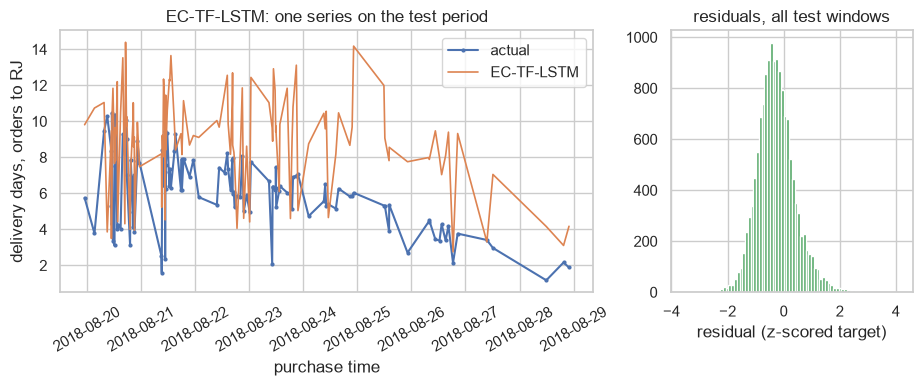

EC-TF-LSTM: params 5,537 | epochs 7 (best 2) | 1.3s/epoch | total 10s | test rmse_days 4.9160, mae_days 3.3629, hit3 0.5785, rmse 0.7296, r2_oos 0.5628


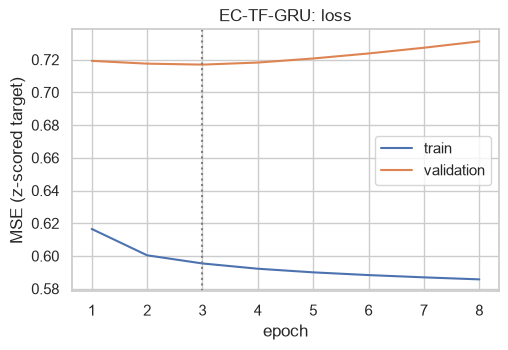

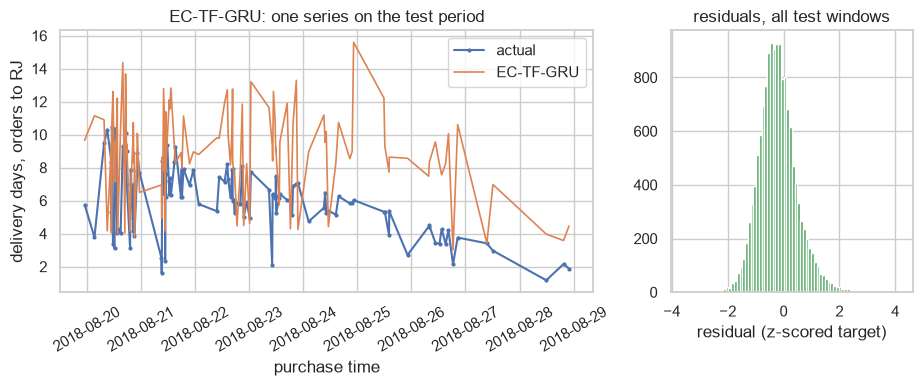

EC-TF-GRU: params 4,257 | epochs 8 (best 3) | 1.5s/epoch | total 13s | test rmse_days 4.8691, mae_days 3.2566, hit3 0.6045, rmse 0.7156, r2_oos 0.5794


In [12]:
run_keras("LSTM"); run_keras("GRU");

## 6. RNN in PyTorch — runs `EC-PT-RNN`, `EC-PT-LSTM`, `EC-PT-GRU`

`nn.RNN(10, 32, batch_first=True)` + `nn.Linear(32, 1)`, loop `zero_grad → forward → backward → clip_grad_norm_ → step` written out. Weights are stored transposed (`weight_ih_l0` is $32\times10$), and the second bias `bias_hh_l0` is zeroed and frozen so the core run has the same 1,409 trainable parameters.

In [13]:
class TorchSeq(nn.Module):
    def __init__(self, kind, F, hidden=H):
        super().__init__()
        self.rnn = {"RNN": nn.RNN, "LSTM": nn.LSTM, "GRU": nn.GRU}[kind](F, hidden, batch_first=True)   # nn.RNN: tanh by default
        self.head = nn.Linear(hidden, 1)
    def forward(self, x):
        out, _ = self.rnn(x)                                         # out: (N, T, H), every h_t
        return self.head(out[:, -1]).squeeze(-1)                     # many-to-one: only h_T is used

def build_torch(kind, F, copy_init=None):
    torch.manual_seed(SEED); m = TorchSeq(kind, F)
    if copy_init is not None:                                        # PyTorch stores W_ih (H,F) and W_hh (H,H): transposes of ours
        with torch.no_grad():
            m.rnn.weight_ih_l0.copy_(torch.from_numpy(copy_init["Wxh"].T)); m.rnn.weight_hh_l0.copy_(torch.from_numpy(copy_init["Whh"].T))
            m.rnn.bias_ih_l0.copy_(torch.from_numpy(copy_init["bh"])); m.rnn.bias_hh_l0.zero_()
            m.head.weight.copy_(torch.from_numpy(copy_init["Why"].T)); m.head.bias.copy_(torch.from_numpy(copy_init["by"]))
        m.rnn.bias_hh_l0.requires_grad_(False)                       # second bias frozen at 0 -> same parameters as Keras / scratch
    return m.to(dev)

def n_trainable(m): return sum(p.numel() for p in m.parameters() if p.requires_grad)

def predict_torch(m, X, bs=4096):
    m.eval(); out = []
    with torch.no_grad():
        for i in range(0, len(X), bs): out.append(m(torch.from_numpy(X[i:i + bs]).to(dev)).cpu().numpy())
    return np.concatenate(out)

def fit_torch(m):
    params = [p for p in m.parameters() if p.requires_grad]
    opt = torch.optim.Adam(params, lr=LR, eps=EPS)
    Xt, yt = torch.from_numpy(Xtr).to(dev), torch.from_numpy(ytr).to(dev)
    Xv, yv = torch.from_numpy(Xva).to(dev), torch.from_numpy(yva).to(dev)
    gen = torch.Generator().manual_seed(SEED)
    hist = {"loss": [], "val_loss": []}; times = []; best, wait, best_state = np.inf, 0, None
    t_all = time.perf_counter()
    for ep in range(MAX_EPOCHS):
        t0 = time.perf_counter(); m.train(); perm = torch.randperm(len(Xt), generator=gen).to(dev); tot = torch.zeros((), device=dev)
        for i in range(0, len(perm), BATCH):
            idx = perm[i:i + BATCH]
            opt.zero_grad(set_to_none=True)
            loss = Fn.mse_loss(m(Xt[idx]), yt[idx]); loss.backward()          # autograd does the BPTT of the scratch section
            torch.nn.utils.clip_grad_norm_(params, CLIP); opt.step()
            tot += loss.detach() * len(idx)
        m.eval()
        with torch.no_grad():
            val = sum(((m(Xv[i:i + 4096]) - yv[i:i + 4096]) ** 2).sum().item() for i in range(0, len(Xv), 4096)) / len(Xv)
        hist["loss"].append(tot.item() / len(perm)); hist["val_loss"].append(val); times.append(time.perf_counter() - t0)
        if val < best - 1e-12: best, wait, best_state = val, 0, {k: v.detach().clone() for k, v in m.state_dict().items()}
        else: wait += 1
        if wait >= PATIENCE: break
    m.load_state_dict(best_state)
    return hist, times, time.perf_counter() - t_all

def run_torch(kind, copy_init=None):
    run_id = f"{CODE}-PT-{kind}"
    m = build_torch(kind, Xtr.shape[2], copy_init)
    hist, times, total = fit_torch(m)
    return finalize(run_id, "PyTorch", kind, hist, n_trainable(m), times, total, lambda X: predict_torch(m, X))

### Same weights, same output

With `W0` loaded, 64 validation windows must give the same predictions in all three implementations ($<10^{-5}$) and the parameter counts must be equal.

In [14]:
xs = Xva[:64]
y_sc = ScratchRNN(F_, H).forward(xs)[0]
y_k = build_keras("RNN", F_, T, W0).predict(xs, verbose=0)[:, 0]
pm = build_torch("RNN", F_, W0); y_p = predict_torch(pm, xs)
print(f"max |scratch - Keras|   = {np.abs(y_sc - y_k).max():.2e}\nmax |scratch - PyTorch| = {np.abs(y_sc - y_p).max():.2e}\nmax |Keras - PyTorch|   = {np.abs(y_k - y_p).max():.2e}")
assert max(np.abs(y_sc - y_k).max(), np.abs(y_sc - y_p).max()) < 1e-5
n_k = build_keras("RNN", F_, T, W0).count_params(); n_p = n_trainable(pm); n_s = ScratchRNN(F_, H).n_params()
print("parameters  scratch / Keras / PyTorch:", n_s, n_k, n_p); assert n_s == n_k == n_p
pc = pd.DataFrame({k: {"Keras": build_keras(k, F_, T).count_params(), "PyTorch (all params)": sum(p.numel() for p in build_torch(k, F_).parameters())}
                   for k in ("RNN", "GRU", "LSTM")}).T
display(pc)

max |scratch - Keras|   = 4.77e-07
max |scratch - PyTorch| = 4.77e-07
max |Keras - PyTorch|   = 4.77e-07
parameters  scratch / Keras / PyTorch: 1409 1409 1409


,Keras,PyTorch (all params)
RNN,1409,1441
GRU,4257,4257
LSTM,5537,5665


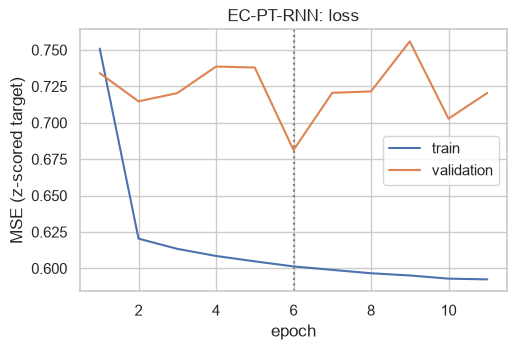

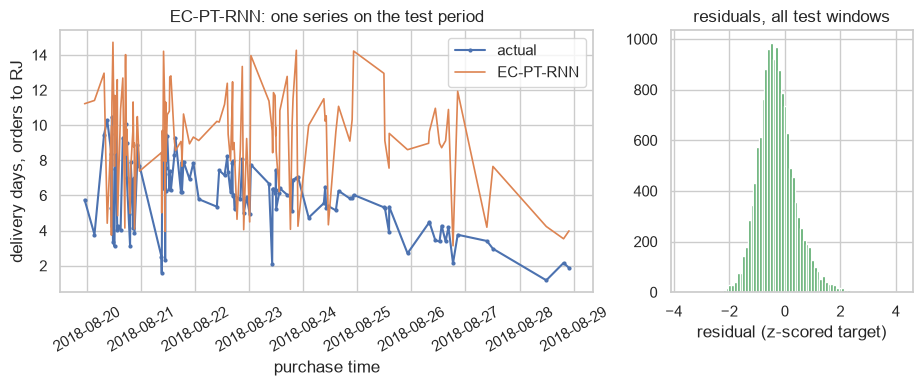

EC-PT-RNN: params 1,409 | epochs 11 (best 6) | 0.8s/epoch | total 9s | test rmse_days 4.9156, mae_days 3.4264, hit3 0.5506, rmse 0.7408, r2_oos 0.5492


In [15]:
run_torch("RNN", copy_init=W0);

**LSTM and GRU in PyTorch** (default uniform init). `nn.LSTM` keeps two biases per gate: $4\cdot32=128$ more parameters than Keras's LSTM; GRU matches Keras.

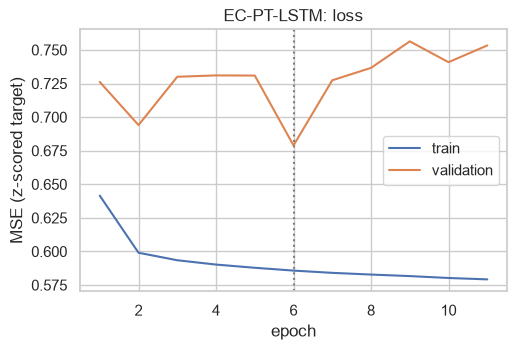

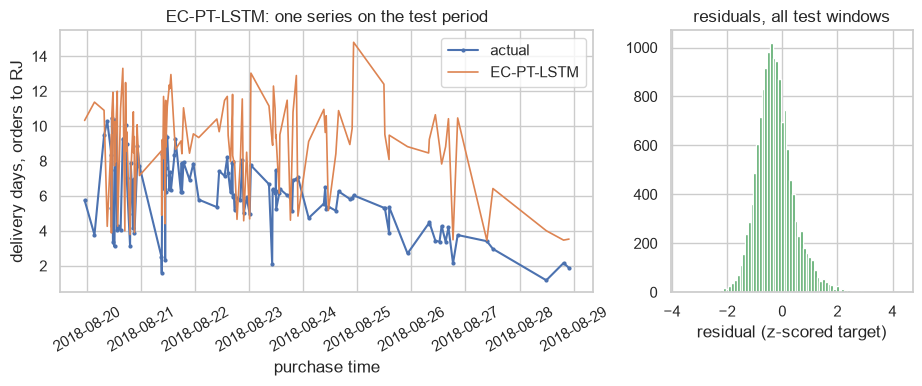

EC-PT-LSTM: params 5,665 | epochs 11 (best 6) | 1.8s/epoch | total 20s | test rmse_days 4.8287, mae_days 3.3005, hit3 0.5815, rmse 0.7214, r2_oos 0.5726


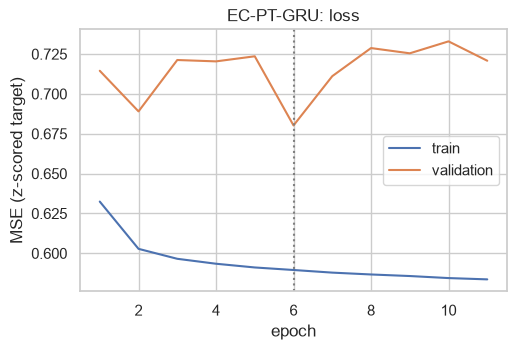

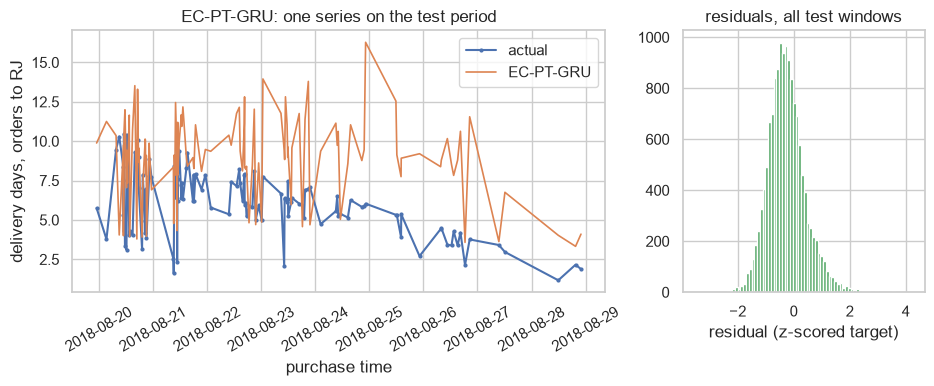

EC-PT-GRU: params 4,257 | epochs 11 (best 6) | 1.5s/epoch | total 18s | test rmse_days 4.8205, mae_days 3.2779, hit3 0.5879, rmse 0.7198, r2_oos 0.5745


In [16]:
run_torch("LSTM"); run_torch("GRU");

## 7. Comparison

Test = the last 15 % of orders by purchase time (2018-06-21 → 2018-08-29). Questions: (a) does the sequence model beat the recalibrated promise and the linear model on the same 100 inputs? (b) do the three implementations of the same RNN agree? (c) do gates help?

In [17]:
rows = []
for name, p in BASELINES.items():
    rows.append(dict(run_id=f"baseline: {name}", impl="-", **metrics_fn(yte, p)))
for rid, r in RUNS.items():
    rows.append(dict(run_id=rid, impl=r["impl"], params=r["params"], epochs=r["epochs_run"], best_epoch=r["best_epoch"],
                     s_per_epoch=round(r["time_per_epoch_s"], 2), total_s=round(r["total_time_s"]), infer_ms_per_1k=round(r["infer_ms_per_1k"], 2), **r["test"]))
table = pd.DataFrame(rows).set_index("run_id")
table.to_csv(RES / f"{CODE}_comparison.csv")
display(table.style.format(precision=4, na_rep="").background_gradient(subset=[KEY_METRIC], cmap="Greens_r"))

,impl,rmse_days,mae_days,hit3,rmse,r2_oos,params,epochs,best_epoch,s_per_epoch,total_s,infer_ms_per_1k
run_id,,,,,,,,,,,,
baseline: train mean,-,6.2279,5.0199,0.2827,1.1034,0.0000,,,,,,
baseline: recent state mean (last 7 days),-,5.2151,3.4438,0.5660,0.8021,0.4716,,,,,,
baseline: promise regression (OLS on promised days),-,5.4078,3.6820,0.5383,0.8163,0.4527,,,,,,
baseline: linear model on window (OLS),-,5.2629,3.8280,0.4896,0.7920,0.4848,,,,,,
EC-SC-RNN,Scratch,5.0136,3.5049,0.5461,0.7458,0.5432,1409.0000,11.0000,6.0000,0.2400,3.0000,1.2400
EC-TF-RNN,Keras,4.9676,3.4069,0.5718,0.7340,0.5575,1409.0000,14.0000,9.0000,0.6300,10.0000,4.3900
EC-TF-LSTM,Keras,4.9160,3.3629,0.5785,0.7296,0.5628,5537.0000,7.0000,2.0000,1.3000,10.0000,6.4900
EC-TF-GRU,Keras,4.8691,3.2566,0.6045,0.7156,0.5794,4257.0000,8.0000,3.0000,1.4800,13.0000,6.1800
EC-PT-RNN,PyTorch,4.9156,3.4264,0.5506,0.7408,0.5492,1409.0000,11.0000,6.0000,0.7900,9.0000,1.3000


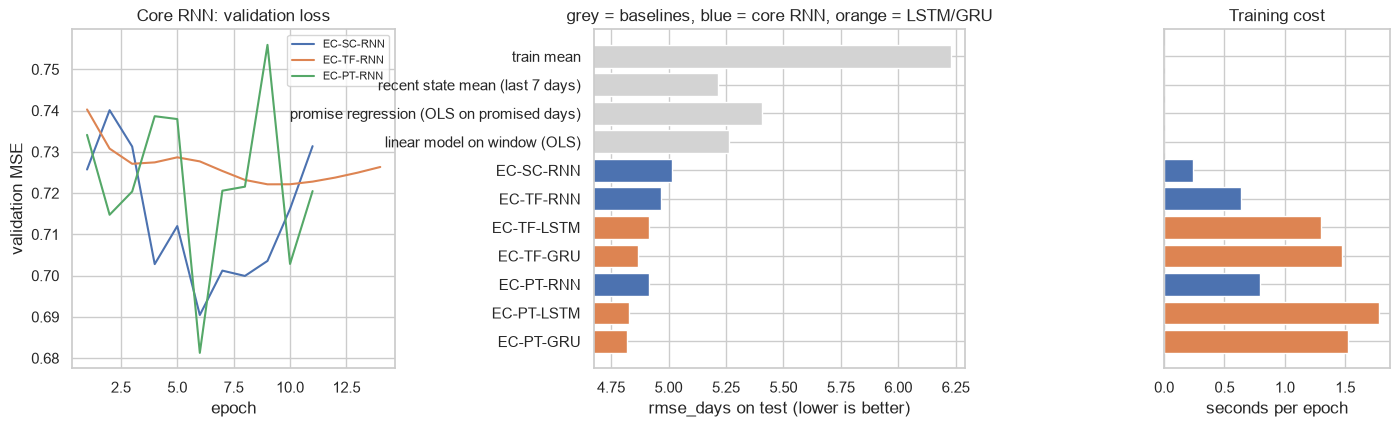

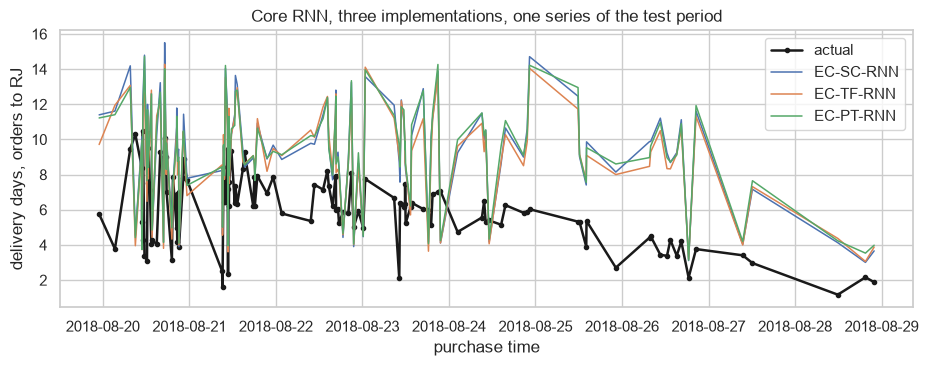

mean |difference| between implementations' test predictions (z units): {'SC-TF': 0.0819, 'SC-PT': 0.0697, 'TF-PT': 0.0852}


In [18]:
core = [f"{CODE}-SC-RNN", f"{CODE}-TF-RNN", f"{CODE}-PT-RNN"]
fig = plt.figure(figsize=(17, 4.4)); gs = fig.add_gridspec(1, 3, wspace=0.65, width_ratios=[1, 1.15, 0.7])
a0 = fig.add_subplot(gs[0]); a1 = fig.add_subplot(gs[1]); a2 = fig.add_subplot(gs[2], sharey=a1)
for rid in core:
    h = RUNS[rid]["history"]; a0.plot(range(1, len(h["val_loss"]) + 1), h["val_loss"], label=rid)
a0.set(xlabel="epoch", ylabel="validation MSE", title="Core RNN: validation loss"); a0.legend(fontsize=8)
labels = list(BASELINES) + list(RUNS)
vals = [metrics_fn(yte, p)[KEY_METRIC] for p in BASELINES.values()] + [RUNS[r]["test"][KEY_METRIC] for r in RUNS]
colors = ["lightgrey"] * len(BASELINES) + ["C0" if r in core else "C1" for r in RUNS]
a1.barh(labels, vals, color=colors); a1.invert_yaxis(); a1.set_xlim(min(vals) * 0.97, max(vals) * 1.01)
a1.set(xlabel=f"{KEY_METRIC} on test (lower is better)", title="grey = baselines, blue = core RNN, orange = LSTM/GRU")
a2.barh(labels, [0] * len(BASELINES) + [RUNS[r]["time_per_epoch_s"] for r in RUNS], color=colors)
a2.set(xlabel="seconds per epoch", title="Training cost"); plt.setp(a2.get_yticklabels(), visible=False)
fig.savefig(IMG / f"{CODE}_compare.png"); plt.show()

fig, ax = plt.subplots(figsize=(11, 3.6))
xs, actual, _, xlabel, ylabel = overlay_slice(RUNS[core[0]]["pred"])
ax.plot(xs, actual, c="k", lw=1.8, marker=".", label="actual")
for rid in core: ax.plot(xs, overlay_slice(RUNS[rid]["pred"])[2], lw=1.1, label=rid)
ax.set(xlabel=xlabel, ylabel=ylabel, title="Core RNN, three implementations, one series of the test period"); ax.legend()
fig.savefig(IMG / f"{CODE}_overlay.png"); plt.show()

P = np.stack([RUNS[r]["pred"] for r in core])
print("mean |difference| between implementations' test predictions (z units):",
      {f"{a[3:5]}-{b[3:5]}": round(float(np.abs(P[i] - P[j]).mean()), 4) for i, a in enumerate(core) for j, b in enumerate(core) if i < j})

## 8. Conclusion

1. **The sequence of recent orders helps.** All seven recurrent models beat every baseline: test RMSE 4.82–5.01 days vs 5.22 for the *recent state mean*, 5.26 for the linear model on the same 100 inputs, 5.41 for Olist's promise recalibrated by least squares and 6.23 for the train mean; $R^2_{oos}$ 0.54–0.58 vs 0.47–0.48. Reading the last orders of a state non-linearly (distance × congestion × weekday) is worth about 0.3–0.4 days of RMSE over the best simple rule.
2. **The promise is a poor forecast as given.** Olist's median promise is 23 days for a median delivery of 10; even after recalibration it explains less than the plain "last week's speed to this state" rule. That is the signal a service operator would want: recent delivery performance beats the static promise.
3. **Scratch, Keras and PyTorch agree.** From identical weights the forward passes differ by < 5e-7 with 1,409 parameters each; trained, the core RNN reaches 5.01 / 4.97 / 4.92 days (scratch / Keras / PyTorch). The 2 % spread comes from batch order and the stopping epoch (best epoch 6, 9, 6) on a small training set (67k windows), not from different maths.
4. **Gates help here.** LSTM and GRU reach 4.82–4.92 days (best: PyTorch GRU 4.82, $\pm3$-day hit rate 59–60 %), 1–3 % better than the vanilla RNN. The vanilla RNN passes only 2 % of the gradient to the oldest of the 10 orders, so the gates' additive memory is what lets the model use the full history.
5. **Cost and caveat.** Per epoch: scratch 0.24 s, Keras 0.6 s, PyTorch 0.8 s (RNN), 1.3–1.8 s for LSTM/GRU on CPU. With ~96k windows (below the 300k of assignment 05, accepted to keep the dataset within 100–150 MB) results vary more between runs; one seed, one split, test period 2018-06-21 → 2018-08-29 (the late-May truckers' strike falls in validation).